In [7]:
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))
from _utils._utils_functions import functions

In [17]:
okabe_ito_colors = np.array(["#000000", "#E69F00", "#56B4E9", "#009E73", "#F0E442",
          "#0072B2","#D55E00", "#CC79A7", "#999999"])

In [8]:
x_ = np.linspace(0, 1, 100)
x = 6*(x_ - 0.5)

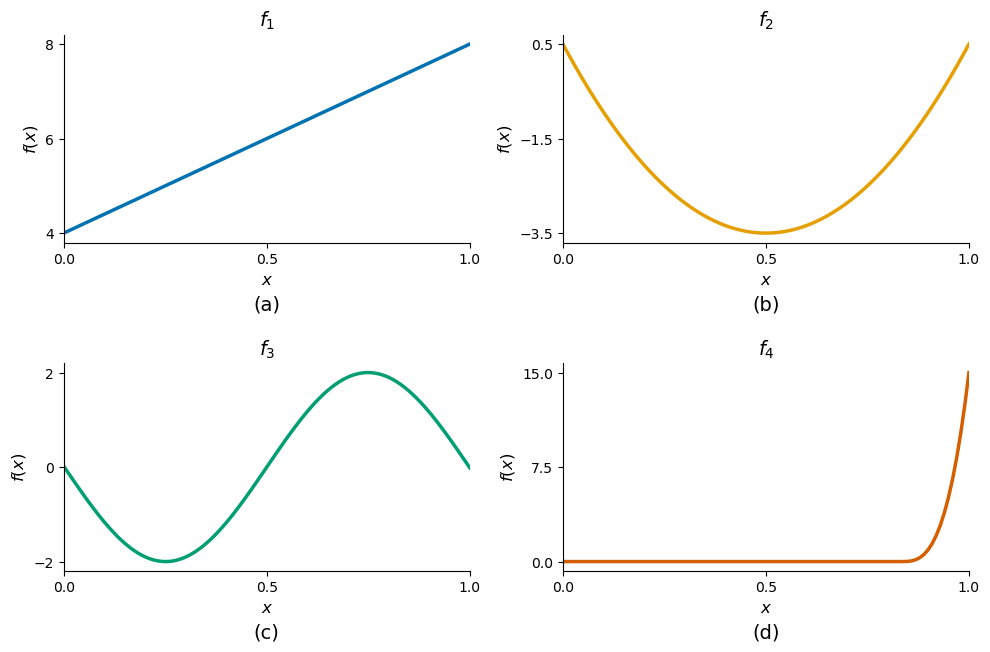

In [23]:
x_ = np.linspace(0, 1, 100)

# Map [0, 1] -> [-3, 3]
x = 6 * (x_ - 0.5)

function_names = ['f1', 'f2', 'f3', 'f4']

# Use colours from the same Okabe–Ito palette
colors = okabe_ito_colors[[5, 1, 3, 6]]

fig, axes = plt.subplots(2, 2, figsize=(10, 7))

panel_labels = ["(a)", "(b)", "(c)", "(d)"]

for i, (ax, f_str) in enumerate(zip(axes.flat, function_names)):

    f = functions[f_str]

    # Evaluate on original domain [-3, 3] and centre
    y = f(x)
    # y = y - np.mean(y)

    ax.plot(
        x_,
        y,
        color=colors[i],
        lw=2.5,
    )

    ax.set_xlim(0, 1)

    ax.set_title(
        fr"$f_{f_str[-1]}$",
        fontsize=14
    )

    ax.set_xlabel(r"$x$", fontsize=12)
    ax.set_ylabel(r"$f(x)$", fontsize=12)

    # Keep the number of ticks small
    ax.set_xticks([0, 0.5, 1])

    y_min, y_max = np.min(y), np.max(y)
    ax.set_yticks(np.linspace(y_min, y_max, 3))

    # Remove unnecessary spines
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Panel label underneath
    ax.text(
        0.5,
        -0.25,
        panel_labels[i],
        transform=ax.transAxes,
        ha="center",
        va="top",
        fontsize=14,
    )

plt.tight_layout(
    rect=[0, 0.04, 1, 1]
)

plt.savefig(
    "figure_functions.pdf",
    bbox_inches="tight",
    dpi=300,
)

plt.show()

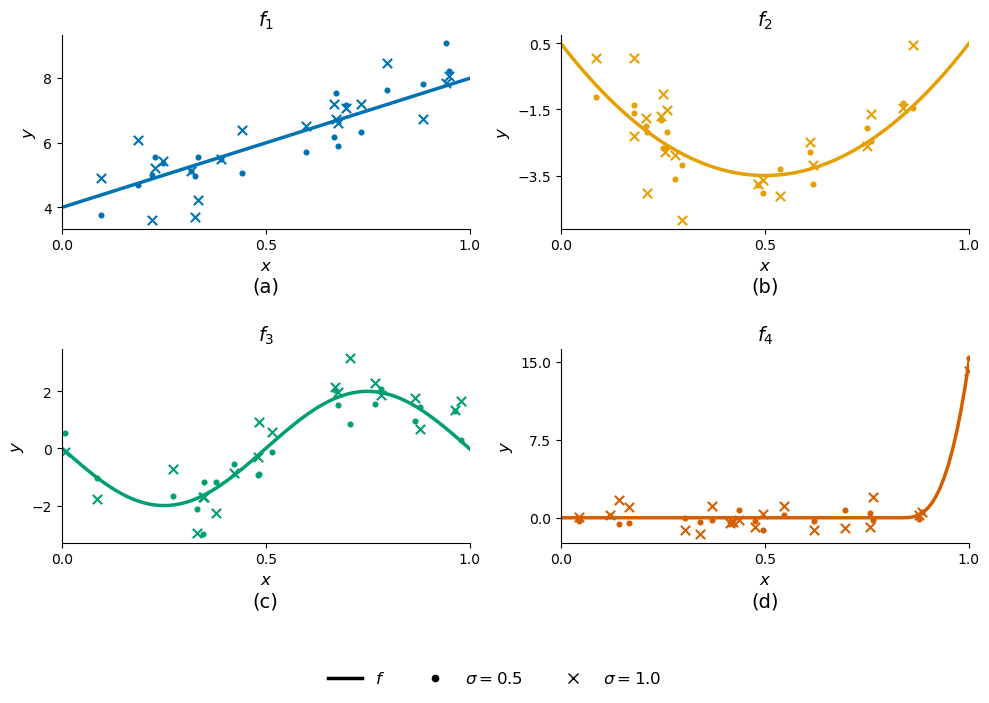

In [27]:
x_ = np.linspace(0, 1, 100)

# Map [0, 1] -> [-3, 3]
x = 6 * (x_ - 0.5)

function_names = ['f1', 'f2', 'f3', 'f4']

# Use colours from the same Okabe–Ito palette
colors = okabe_ito_colors[[5, 1, 3, 6]]

fig, axes = plt.subplots(2, 2, figsize=(10, 7))

panel_labels = ["(a)", "(b)", "(c)", "(d)"]

# Generate the same x_i values for both noise levels
rng = np.random.default_rng(12345)
n_obs = 20


for i, (ax, f_str) in enumerate(zip(axes.flat, function_names)):

    f = functions[f_str]

    # True function
    y = f(x)

    # Observations for sigma = 0.5 and sigma = 1.0
    x_i = rng.uniform(0, 1, n_obs)
    x_obs = 6 * (x_i - 0.5)
    y_true_obs = f(x_obs)

    y_obs_05 = y_true_obs + 0.5 * rng.standard_normal(n_obs)
    y_obs_10 = y_true_obs + 1.0 * rng.standard_normal(n_obs)

    # True function
    ax.plot(
        x_,
        y,
        color=colors[i],
        lw=2.5,
        label=r"$f$",
    )

    # Noisy observations
    ax.scatter(
        x_i,
        y_obs_05,
        color=colors[i],
        marker=".",
        s=45,
        label=r"$\sigma=0.5$",
    )

    ax.scatter(
        x_i,
        y_obs_10,
        color=colors[i],
        marker="x",
        s=45,
        linewidths=1.5,
        label=r"$\sigma=1.0$",
    )

    ax.set_xlim(0, 1)

    # Expand y-limits to include all observations
    all_y = np.concatenate([y, y_obs_05, y_obs_10])
    y_min = np.min(y)
    y_max = np.max(y)

    y_range = y_max - y_min
    lower = min(y_min, np.min(y_obs_05), np.min(y_obs_10))
    upper = max(y_max, np.max(y_obs_05), np.max(y_obs_10))

    padding = 0.05 * (upper - lower)
    ax.set_ylim(lower - padding, upper + padding)

    ax.set_title(
        fr"$f_{f_str[-1]}$",
        fontsize=14
    )

    ax.set_xlabel(r"$x$", fontsize=12)
    ax.set_ylabel(r"$y$", fontsize=12)

    # Keep the number of ticks small
    ax.set_xticks([0, 0.5, 1.0])
    ax.set_yticks(np.linspace(y_min, y_max, 3))

    # Remove unnecessary spines
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Panel label underneath
    ax.text(
        0.5,
        -0.25,
        panel_labels[i],
        transform=ax.transAxes,
        ha="center",
        va="top",
        fontsize=14,
    )

# Single legend beneath all plots
handles = [
    plt.Line2D([], [], color="black", lw=2.5, label=r"$f$"),
    plt.Line2D([], [], color="black", marker=".", linestyle="None",
               markersize=9, label=r"$\sigma=0.5$"),
    plt.Line2D([], [], color="black", marker="x", linestyle="None",
               markersize=7, label=r"$\sigma=1.0$"),
]

fig.legend(
    handles=handles,
    loc="lower center",
    ncol=3,
    bbox_to_anchor=(0.5, -0.01),
    frameon=False,
    fontsize=12,
)

plt.tight_layout(
    rect=[0, 0.08, 1, 1]
)

plt.savefig(
    "figure_functions.pdf",
    bbox_inches="tight",
    dpi=300,
)

plt.show()